# 🍅 Kolar Tomato Price Prediction — April 2026
### Random Forest Model | Kolar District, Karnataka

This notebook builds a **Random Forest** model to predict daily tomato prices for **all 30 days of April 2026** using historical data from January 2016 to February 2026.

**Target variable:** `avg_price_rs_per_quintal`

---

## 📦 Step 1: Install & Import Libraries

In [1]:
# Install any missing libraries (usually pre-installed in Colab)
!pip install -q scikit-learn pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📂 Step 2: Upload & Load Data

Upload the file `kolar_tomato_prices_2016_2026.csv` when prompted.

In [3]:
from google.colab import files

print('📤 Please upload your CSV file...')
uploaded = files.upload()

import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f'\n✅ File "{filename}" loaded successfully!')
print(f'📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns')

📤 Please upload your CSV file...


Saving kolar_tomato_prices_2016_2026.csv to kolar_tomato_prices_2016_2026.csv

✅ File "kolar_tomato_prices_2016_2026.csv" loaded successfully!
📊 Shape: 3712 rows × 7 columns


## 🔍 Step 3: Exploratory Data Analysis (EDA)

In [4]:
# Basic info
print('=== DATASET OVERVIEW ===')
print(df.info())
print('\n=== FIRST 5 ROWS ===')
df.head()

=== DATASET OVERVIEW ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3712 entries, 0 to 3711
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   date                        3712 non-null   object 
 1   district                    3712 non-null   object 
 2   commodity                   3712 non-null   object 
 3   min_price_rs_per_quintal    3712 non-null   float64
 4   modal_price_rs_per_quintal  3712 non-null   float64
 5   max_price_rs_per_quintal    3712 non-null   float64
 6   avg_price_rs_per_quintal    3712 non-null   float64
dtypes: float64(4), object(3)
memory usage: 203.1+ KB
None

=== FIRST 5 ROWS ===


,date,district,commodity,min_price_rs_per_quintal,modal_price_rs_per_quintal,max_price_rs_per_quintal,avg_price_rs_per_quintal
0,2016-01-01,Kolar,Tomato,693.21,864.77,1049.50,871.35
1,2016-01-02,Kolar,Tomato,657.36,793.84,914.75,786.06
2,2016-01-03,Kolar,Tomato,729.11,893.41,983.59,856.35
3,2016-01-04,Kolar,Tomato,885.26,1003.71,1164.69,1024.97
4,2016-01-05,Kolar,Tomato,659.10,798.10,979.62,819.36


In [5]:
print('=== DESCRIPTIVE STATISTICS ===')
df.describe().round(2)

=== DESCRIPTIVE STATISTICS ===


,min_price_rs_per_quintal,modal_price_rs_per_quintal,max_price_rs_per_quintal,avg_price_rs_per_quintal
count,3712.00,3712.00,3712.00,3712.00
mean,828.19,1005.65,1232.00,1030.09
std,221.91,263.50,330.85,273.25
min,163.51,200.00,255.35,209.43
25%,659.30,803.44,982.19,823.55
50%,824.89,1000.65,1225.86,1028.95
75%,988.92,1203.10,1476.79,1235.03
max,1514.15,1724.00,2183.68,1833.08


In [6]:
# Check missing values
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing: {missing.sum()}')

=== MISSING VALUES ===
date                          0
district                      0
commodity                     0
min_price_rs_per_quintal      0
modal_price_rs_per_quintal    0
max_price_rs_per_quintal      0
avg_price_rs_per_quintal      0
dtype: int64

Total missing: 0


In [7]:
# Parse dates
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f'Date range: {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Total days: {(df["date"].max() - df["date"].min()).days + 1}')
print(f'Actual records: {len(df)}')

Date range: 2016-01-01 → 2026-02-28
Total days: 3712
Actual records: 3712


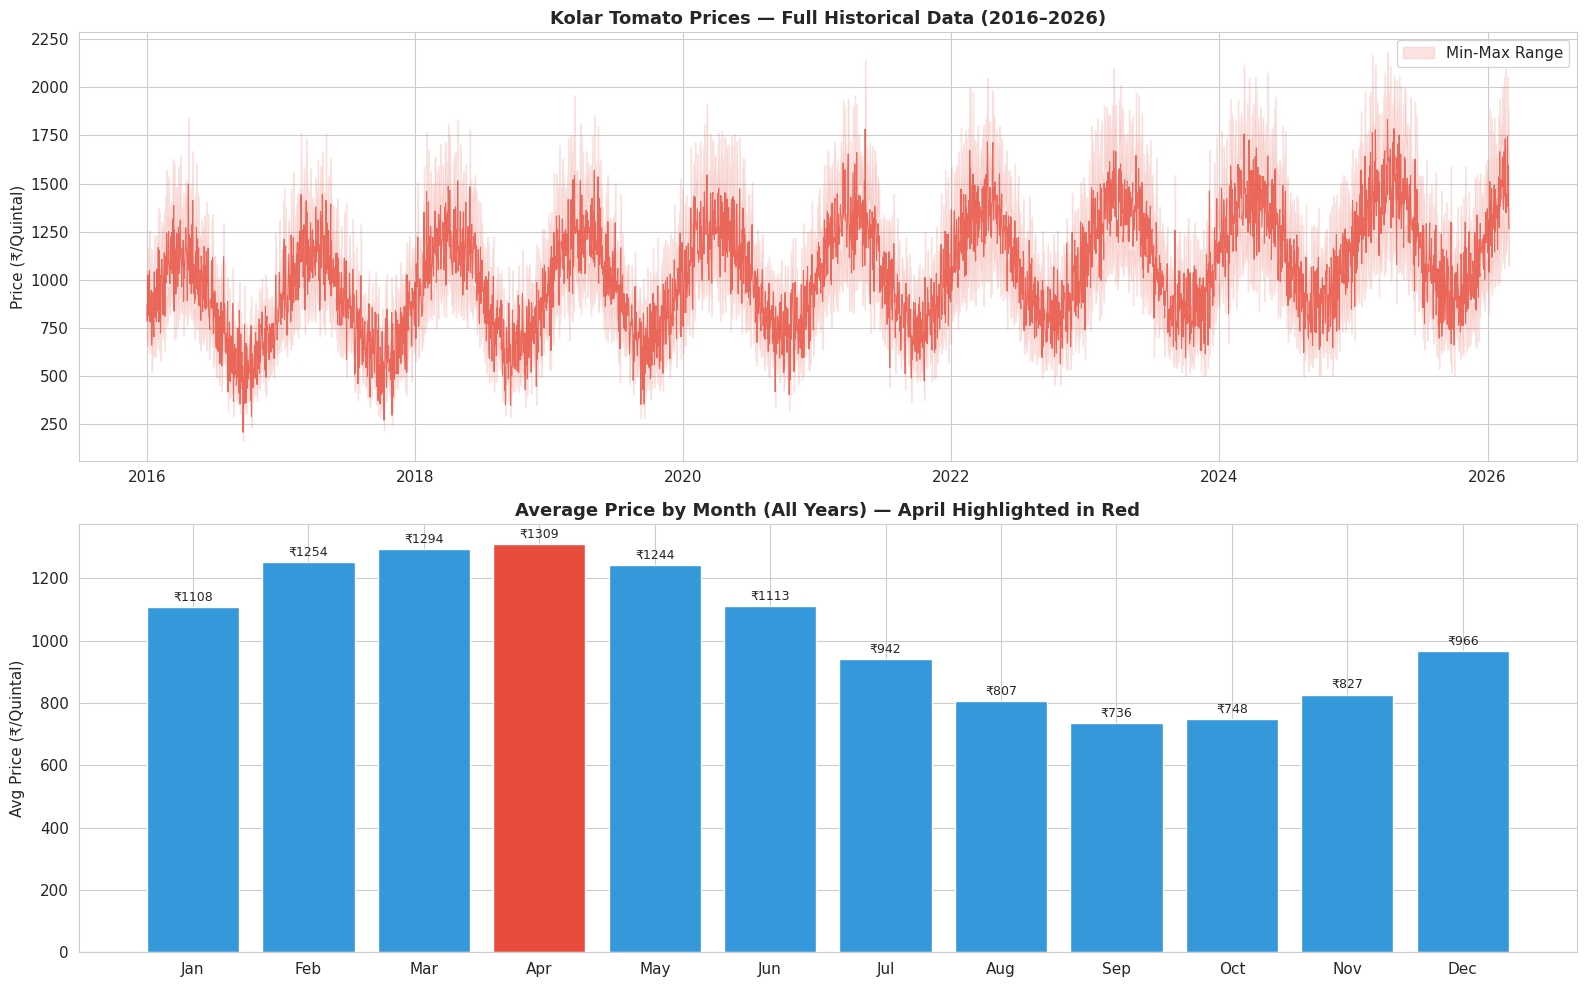

✅ EDA charts saved!


In [8]:
# Plot full historical price trend
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Full history
axes[0].plot(df['date'], df['avg_price_rs_per_quintal'], color='#e74c3c', linewidth=0.8, alpha=0.8)
axes[0].fill_between(df['date'], df['min_price_rs_per_quintal'], df['max_price_rs_per_quintal'],
                     alpha=0.15, color='#e74c3c', label='Min-Max Range')
axes[0].set_title('Kolar Tomato Prices — Full Historical Data (2016–2026)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (₹/Quintal)')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Monthly average (seasonal pattern)
df['month'] = df['date'].dt.month
monthly_avg = df.groupby('month')['avg_price_rs_per_quintal'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
colors = ['#e74c3c' if m == 4 else '#3498db' for m in range(1, 13)]
axes[1].bar(month_names, monthly_avg.values, color=colors, edgecolor='white')
axes[1].set_title('Average Price by Month (All Years) — April Highlighted in Red', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Price (₹/Quintal)')
for i, v in enumerate(monthly_avg.values):
    axes[1].text(i, v + 20, f'₹{v:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_price_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA charts saved!')

## 🔧 Step 4: Feature Engineering

We create rich time-series features so Random Forest can learn seasonality, trends, and recent momentum.

In [9]:
def build_features(df):
    """Create comprehensive time-series features for the model."""
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])

    # ── Calendar features ──────────────────────────────────────────────
    df['year']           = df['date'].dt.year
    df['month']          = df['date'].dt.month
    df['day']            = df['date'].dt.day
    df['day_of_week']    = df['date'].dt.dayofweek        # 0=Monday
    df['day_of_year']    = df['date'].dt.dayofyear
    df['week_of_year']   = df['date'].dt.isocalendar().week.astype(int)
    df['quarter']        = df['date'].dt.quarter
    df['is_weekend']     = (df['day_of_week'] >= 5).astype(int)

    # ── Cyclical encoding (captures seasonal periodicity) ──────────────
    df['month_sin']      = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos']      = np.cos(2 * np.pi * df['month'] / 12)
    df['day_sin']        = np.sin(2 * np.pi * df['day'] / 31)
    df['day_cos']        = np.cos(2 * np.pi * df['day'] / 31)
    df['dow_sin']        = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos']        = np.cos(2 * np.pi * df['day_of_week'] / 7)
    df['doy_sin']        = np.sin(2 * np.pi * df['day_of_year'] / 365)
    df['doy_cos']        = np.cos(2 * np.pi * df['day_of_year'] / 365)

    # ── Price spread features ──────────────────────────────────────────
    df['price_spread']   = df['max_price_rs_per_quintal'] - df['min_price_rs_per_quintal']
    df['modal_avg_diff'] = df['modal_price_rs_per_quintal'] - df['avg_price_rs_per_quintal']

    # ── Lag features (recent price history) ───────────────────────────
    for lag in [1, 2, 3, 5, 7, 14, 21, 28, 30]:
        df[f'lag_{lag}']         = df['avg_price_rs_per_quintal'].shift(lag)
        df[f'modal_lag_{lag}']   = df['modal_price_rs_per_quintal'].shift(lag)

    # ── Rolling statistics ─────────────────────────────────────────────
    for window in [7, 14, 30, 60, 90]:
        df[f'rolling_mean_{window}']  = df['avg_price_rs_per_quintal'].shift(1).rolling(window).mean()
        df[f'rolling_std_{window}']   = df['avg_price_rs_per_quintal'].shift(1).rolling(window).std()
        df[f'rolling_max_{window}']   = df['avg_price_rs_per_quintal'].shift(1).rolling(window).max()
        df[f'rolling_min_{window}']   = df['avg_price_rs_per_quintal'].shift(1).rolling(window).min()

    # ── Exponentially weighted moving average (EWMA) ───────────────────
    for span in [7, 14, 30]:
        df[f'ewma_{span}']  = df['avg_price_rs_per_quintal'].shift(1).ewm(span=span).mean()

    # ── Momentum / trend features ──────────────────────────────────────
    df['price_change_1d']    = df['avg_price_rs_per_quintal'].diff(1)
    df['price_change_7d']    = df['avg_price_rs_per_quintal'].diff(7)
    df['price_change_30d']   = df['avg_price_rs_per_quintal'].diff(30)
    df['pct_change_1d']      = df['avg_price_rs_per_quintal'].pct_change(1)
    df['pct_change_7d']      = df['avg_price_rs_per_quintal'].pct_change(7)

    # ── Same-month historical statistics (year-over-year context) ──────
    monthly_stats = df.groupby('month')['avg_price_rs_per_quintal'].agg(['mean','std','median'])
    monthly_stats.columns = ['hist_month_mean','hist_month_std','hist_month_median']
    df = df.merge(monthly_stats, on='month', how='left')

    # ── Year trend (linear index) ──────────────────────────────────────
    min_year = df['year'].min()
    df['year_trend'] = df['year'] - min_year

    # ── April indicator ────────────────────────────────────────────────
    df['is_april'] = (df['month'] == 4).astype(int)

    return df

df_feat = build_features(df)
print(f'✅ Feature engineering complete!')
print(f'Total features created: {len(df_feat.columns)} columns')

✅ Feature engineering complete!
Total features created: 76 columns


## 🤖 Step 5: Model Training

In [10]:
# ── Define feature columns ─────────────────────────────────────────────
EXCLUDE = ['date', 'district', 'commodity',
           'avg_price_rs_per_quintal',        # target
           'min_price_rs_per_quintal',         # future-leaking in production
           'max_price_rs_per_quintal',
           'modal_price_rs_per_quintal']

FEATURE_COLS = [c for c in df_feat.columns if c not in EXCLUDE]
TARGET       = 'avg_price_rs_per_quintal'

# Drop rows where lag features create NaNs
df_model = df_feat[FEATURE_COLS + [TARGET, 'date']].dropna().copy()

print(f'Training samples after dropping NaN lag rows: {len(df_model)}')
print(f'Feature count: {len(FEATURE_COLS)}')
print(f'Training date range: {df_model["date"].min().date()} → {df_model["date"].max().date()}')

Training samples after dropping NaN lag rows: 3622
Feature count: 69
Training date range: 2016-03-31 → 2026-02-28


In [11]:
# ── Time-based train/test split (last 6 months = test) ────────────────
# We keep chronological order — DO NOT shuffle time-series data!
SPLIT_DATE = '2025-09-01'

train_df = df_model[df_model['date'] < SPLIT_DATE].copy()
test_df  = df_model[df_model['date'] >= SPLIT_DATE].copy()

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET]
X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET]

print(f'Train size : {len(X_train)} samples  ({train_df["date"].min().date()} → {train_df["date"].max().date()})')
print(f'Test size  : {len(X_test)} samples   ({test_df["date"].min().date()} → {test_df["date"].max().date()})')

Train size : 3441 samples  (2016-03-31 → 2025-08-31)
Test size  : 181 samples   (2025-09-01 → 2026-02-28)


In [12]:
# ── Train the Random Forest model ─────────────────────────────────────
print('⏳ Training Random Forest... (this may take 1–2 minutes)')

rf_model = RandomForestRegressor(
    n_estimators      = 500,       # number of trees
    max_depth         = 20,        # prevent overfitting
    min_samples_split = 5,
    min_samples_leaf  = 2,
    max_features      = 'sqrt',    # feature subsampling per split
    bootstrap         = True,
    random_state      = 42,
    n_jobs            = -1         # use all CPU cores
)

rf_model.fit(X_train, y_train)
print('✅ Model training complete!')

⏳ Training Random Forest... (this may take 1–2 minutes)
✅ Model training complete!


## 📊 Step 6: Model Evaluation

In [13]:
# ── Evaluate on hold-out test set ─────────────────────────────────────
y_pred_test = rf_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2   = r2_score(y_test, y_pred_test)
mape = np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100

print('=' * 50)
print('         MODEL PERFORMANCE (Test Set)')
print('=' * 50)
print(f'  MAE    : ₹{mae:.2f} per quintal')
print(f'  RMSE   : ₹{rmse:.2f} per quintal')
print(f'  MAPE   : {mape:.2f}%')
print(f'  R²     : {r2:.4f}')
print('=' * 50)

# Train set metrics (to check overfitting)
y_pred_train = rf_model.predict(X_train)
r2_train = r2_score(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
print(f'\nTrain MAE: ₹{mae_train:.2f}  |  Train R²: {r2_train:.4f}')
print(f'Test  MAE: ₹{mae:.2f}  |  Test  R²: {r2:.4f}')
if abs(r2_train - r2) < 0.1:
    print('✅ Good generalisation — no significant overfitting.')
else:
    print('⚠️  Possible overfitting — consider reducing max_depth.')

         MODEL PERFORMANCE (Test Set)
  MAE    : ₹43.50 per quintal
  RMSE   : ₹55.62 per quintal
  MAPE   : 3.95%
  R²     : 0.9460

Train MAE: ₹18.93  |  Train R²: 0.9914
Test  MAE: ₹43.50  |  Test  R²: 0.9460
✅ Good generalisation — no significant overfitting.


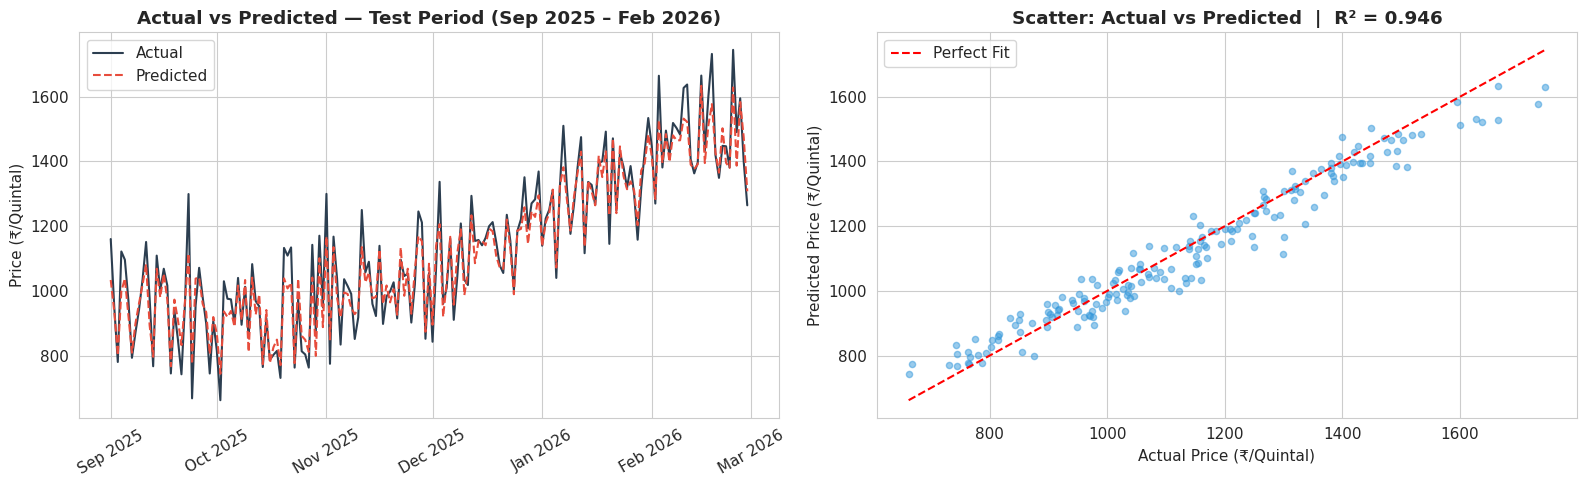

✅ Evaluation charts saved!


In [14]:
# ── Actual vs Predicted plot ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Time series comparison
axes[0].plot(test_df['date'], y_test.values, label='Actual', color='#2c3e50', linewidth=1.5)
axes[0].plot(test_df['date'], y_pred_test,   label='Predicted', color='#e74c3c', linewidth=1.5, linestyle='--')
axes[0].set_title('Actual vs Predicted — Test Period (Sep 2025 – Feb 2026)', fontweight='bold')
axes[0].set_ylabel('Price (₹/Quintal)')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[0].get_xticklabels(), rotation=30)

# Scatter plot
axes[1].scatter(y_test, y_pred_test, alpha=0.5, color='#3498db', s=20)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
axes[1].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Fit')
axes[1].set_xlabel('Actual Price (₹/Quintal)')
axes[1].set_ylabel('Predicted Price (₹/Quintal)')
axes[1].set_title(f'Scatter: Actual vs Predicted  |  R² = {r2:.3f}', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Evaluation charts saved!')

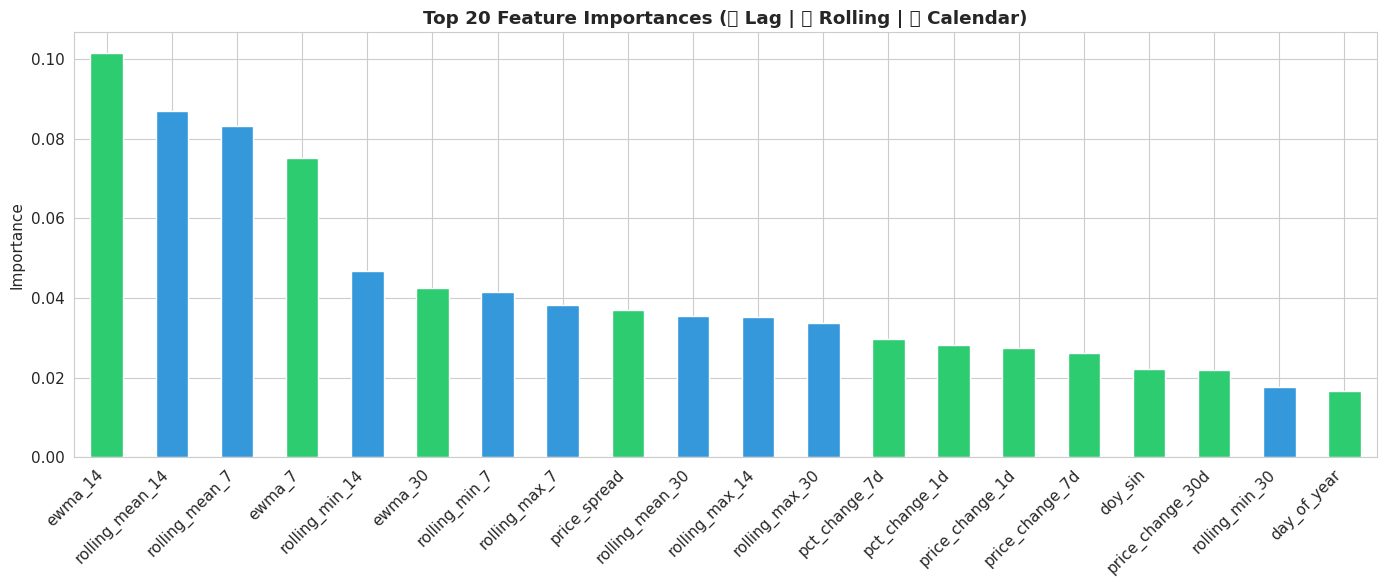


Top 10 most important features:
   1. ewma_14                             0.1016
   2. rolling_mean_14                     0.0869
   3. rolling_mean_7                      0.0831
   4. ewma_7                              0.0752
   5. rolling_min_14                      0.0469
   6. ewma_30                             0.0425
   7. rolling_min_7                       0.0416
   8. rolling_max_7                       0.0382
   9. price_spread                        0.0369
  10. rolling_mean_30                     0.0354


In [15]:
# ── Feature Importance ────────────────────────────────────────────────
feat_imp = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
top20 = feat_imp.head(20)
colors_imp = ['#e74c3c' if 'lag' in f else '#3498db' if 'rolling' in f else '#2ecc71' for f in top20.index]
top20.plot(kind='bar', ax=ax, color=colors_imp, edgecolor='white')
ax.set_title('Top 20 Feature Importances (🔴 Lag | 🔵 Rolling | 🟢 Calendar)', fontweight='bold')
ax.set_ylabel('Importance')
ax.set_xticklabels(top20.index, rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 most important features:')
for i, (feat, imp) in enumerate(feat_imp.head(10).items(), 1):
    print(f'  {i:2d}. {feat:<35} {imp:.4f}')

## 🔮 Step 7: Predict April 2026 (All 30 Days)

We use a **recursive/iterative forecasting** strategy:
- For each April day, we build its features using all data up to that point (including previously predicted days).
- This mirrors real-world forecasting where future actuals are unknown.

In [16]:
def predict_april_2026(model, df_history, feature_cols):
    """
    Iteratively predict each day in April 2026.
    Each prediction uses previously predicted prices as lag values.
    """
    # Work on a copy that we'll extend day-by-day
    df_ext = df_history[['date','avg_price_rs_per_quintal',
                          'modal_price_rs_per_quintal',
                          'min_price_rs_per_quintal',
                          'max_price_rs_per_quintal']].copy()

    # We'll fill in modal/min/max with rolling estimates for future rows
    april_dates = pd.date_range(start='2026-04-01', end='2026-04-30', freq='D')
    predictions = []

    for pred_date in april_dates:
        # Estimate spread cols using last 30-day average spread
        recent = df_ext.tail(30)
        avg_spread    = (recent['max_price_rs_per_quintal'] - recent['min_price_rs_per_quintal']).mean()
        avg_modal_diff = (recent['modal_price_rs_per_quintal'] - recent['avg_price_rs_per_quintal']).mean()
        last_avg       = df_ext['avg_price_rs_per_quintal'].iloc[-1]

        # Build temporary future row
        future_row = pd.DataFrame([{
            'date'                       : pred_date,
            'avg_price_rs_per_quintal'   : np.nan,   # to be predicted
            'modal_price_rs_per_quintal' : last_avg + avg_modal_diff,
            'min_price_rs_per_quintal'   : last_avg - avg_spread / 2,
            'max_price_rs_per_quintal'   : last_avg + avg_spread / 2,
        }])

        # Append future row and rebuild all features
        df_tmp = pd.concat([df_ext, future_row], ignore_index=True)
        df_tmp = build_features(df_tmp)

        # Get the feature row for this date
        row = df_tmp[df_tmp['date'] == pred_date][feature_cols].iloc[0:1]

        # Predict
        price_pred = model.predict(row)[0]

        # ── Confidence interval via individual tree predictions ──────────
        tree_preds = np.array([tree.predict(row)[0] for tree in model.estimators_])
        ci_lo = np.percentile(tree_preds, 10)
        ci_hi = np.percentile(tree_preds, 90)

        predictions.append({
            'date'            : pred_date,
            'predicted_avg_price_rs_per_quintal' : round(price_pred, 2),
            'ci_lower_10pct'  : round(ci_lo, 2),
            'ci_upper_90pct'  : round(ci_hi, 2),
        })

        # Feed predicted price back into history for next iteration
        df_ext = pd.concat([df_ext, pd.DataFrame([{
            'date'                       : pred_date,
            'avg_price_rs_per_quintal'   : price_pred,
            'modal_price_rs_per_quintal' : last_avg + avg_modal_diff,
            'min_price_rs_per_quintal'   : last_avg - avg_spread / 2,
            'max_price_rs_per_quintal'   : last_avg + avg_spread / 2,
        }])], ignore_index=True)

        print(f'  {pred_date.strftime("%d %b %Y")}  →  ₹{price_pred:,.2f}   (CI: ₹{ci_lo:,.0f}–₹{ci_hi:,.0f})')

    return pd.DataFrame(predictions)


print('🔮 Predicting tomato prices for April 2026...\n')
april_predictions = predict_april_2026(rf_model, df, FEATURE_COLS)
print(f'\n✅ All 30 days predicted!')

🔮 Predicting tomato prices for April 2026...

  01 Apr 2026  →  ₹1,374.21   (CI: ₹1,245–₹1,497)
  02 Apr 2026  →  ₹1,395.66   (CI: ₹1,274–₹1,512)
  03 Apr 2026  →  ₹1,391.81   (CI: ₹1,239–₹1,525)
  04 Apr 2026  →  ₹1,380.40   (CI: ₹1,239–₹1,500)
  05 Apr 2026  →  ₹1,375.84   (CI: ₹1,240–₹1,496)
  06 Apr 2026  →  ₹1,362.08   (CI: ₹1,233–₹1,485)
  07 Apr 2026  →  ₹1,381.13   (CI: ₹1,241–₹1,529)
  08 Apr 2026  →  ₹1,371.23   (CI: ₹1,240–₹1,497)
  09 Apr 2026  →  ₹1,366.21   (CI: ₹1,248–₹1,479)
  10 Apr 2026  →  ₹1,370.78   (CI: ₹1,247–₹1,496)
  11 Apr 2026  →  ₹1,369.97   (CI: ₹1,244–₹1,504)
  12 Apr 2026  →  ₹1,366.94   (CI: ₹1,250–₹1,486)
  13 Apr 2026  →  ₹1,359.31   (CI: ₹1,238–₹1,478)
  14 Apr 2026  →  ₹1,348.27   (CI: ₹1,227–₹1,463)
  15 Apr 2026  →  ₹1,345.57   (CI: ₹1,225–₹1,463)
  16 Apr 2026  →  ₹1,348.86   (CI: ₹1,226–₹1,470)
  17 Apr 2026  →  ₹1,348.24   (CI: ₹1,216–₹1,471)
  18 Apr 2026  →  ₹1,347.33   (CI: ₹1,225–₹1,463)
  19 Apr 2026  →  ₹1,347.16   (CI: ₹1,229–₹1,469)
  20

In [17]:
# Display the prediction table
april_predictions['day_of_week'] = april_predictions['date'].dt.strftime('%A')
display_df = april_predictions[['date','day_of_week','predicted_avg_price_rs_per_quintal','ci_lower_10pct','ci_upper_90pct']].copy()
display_df.columns = ['Date','Day','Predicted Avg Price (₹/Qtl)','CI Lower (₹)','CI Upper (₹)']
display_df['Date'] = display_df['Date'].dt.strftime('%d-%b-%Y')

print('\n📋 APRIL 2026 TOMATO PRICE PREDICTIONS — KOLAR DISTRICT')
print('=' * 70)
print(display_df.to_string(index=False))
print('=' * 70)
print(f"\n📊 Summary Statistics for April 2026:")
preds = april_predictions['predicted_avg_price_rs_per_quintal']
print(f"  Min Price  : ₹{preds.min():,.2f}")
print(f"  Max Price  : ₹{preds.max():,.2f}")
print(f"  Mean Price : ₹{preds.mean():,.2f}")
print(f"  Std Dev    : ₹{preds.std():,.2f}")


📋 APRIL 2026 TOMATO PRICE PREDICTIONS — KOLAR DISTRICT
       Date       Day  Predicted Avg Price (₹/Qtl)  CI Lower (₹)  CI Upper (₹)
01-Apr-2026 Wednesday                      1374.21       1244.77       1496.87
02-Apr-2026  Thursday                      1395.66       1273.90       1512.21
03-Apr-2026    Friday                      1391.81       1238.99       1525.25
04-Apr-2026  Saturday                      1380.40       1239.11       1499.90
05-Apr-2026    Sunday                      1375.84       1239.96       1495.72
06-Apr-2026    Monday                      1362.08       1232.53       1484.70
07-Apr-2026   Tuesday                      1381.13       1241.26       1528.74
08-Apr-2026 Wednesday                      1371.23       1240.45       1497.07
09-Apr-2026  Thursday                      1366.21       1247.72       1478.93
10-Apr-2026    Friday                      1370.78       1247.25       1496.18
11-Apr-2026  Saturday                      1369.97       1244.06       1504

## 📈 Step 8: Visualise April 2026 Predictions

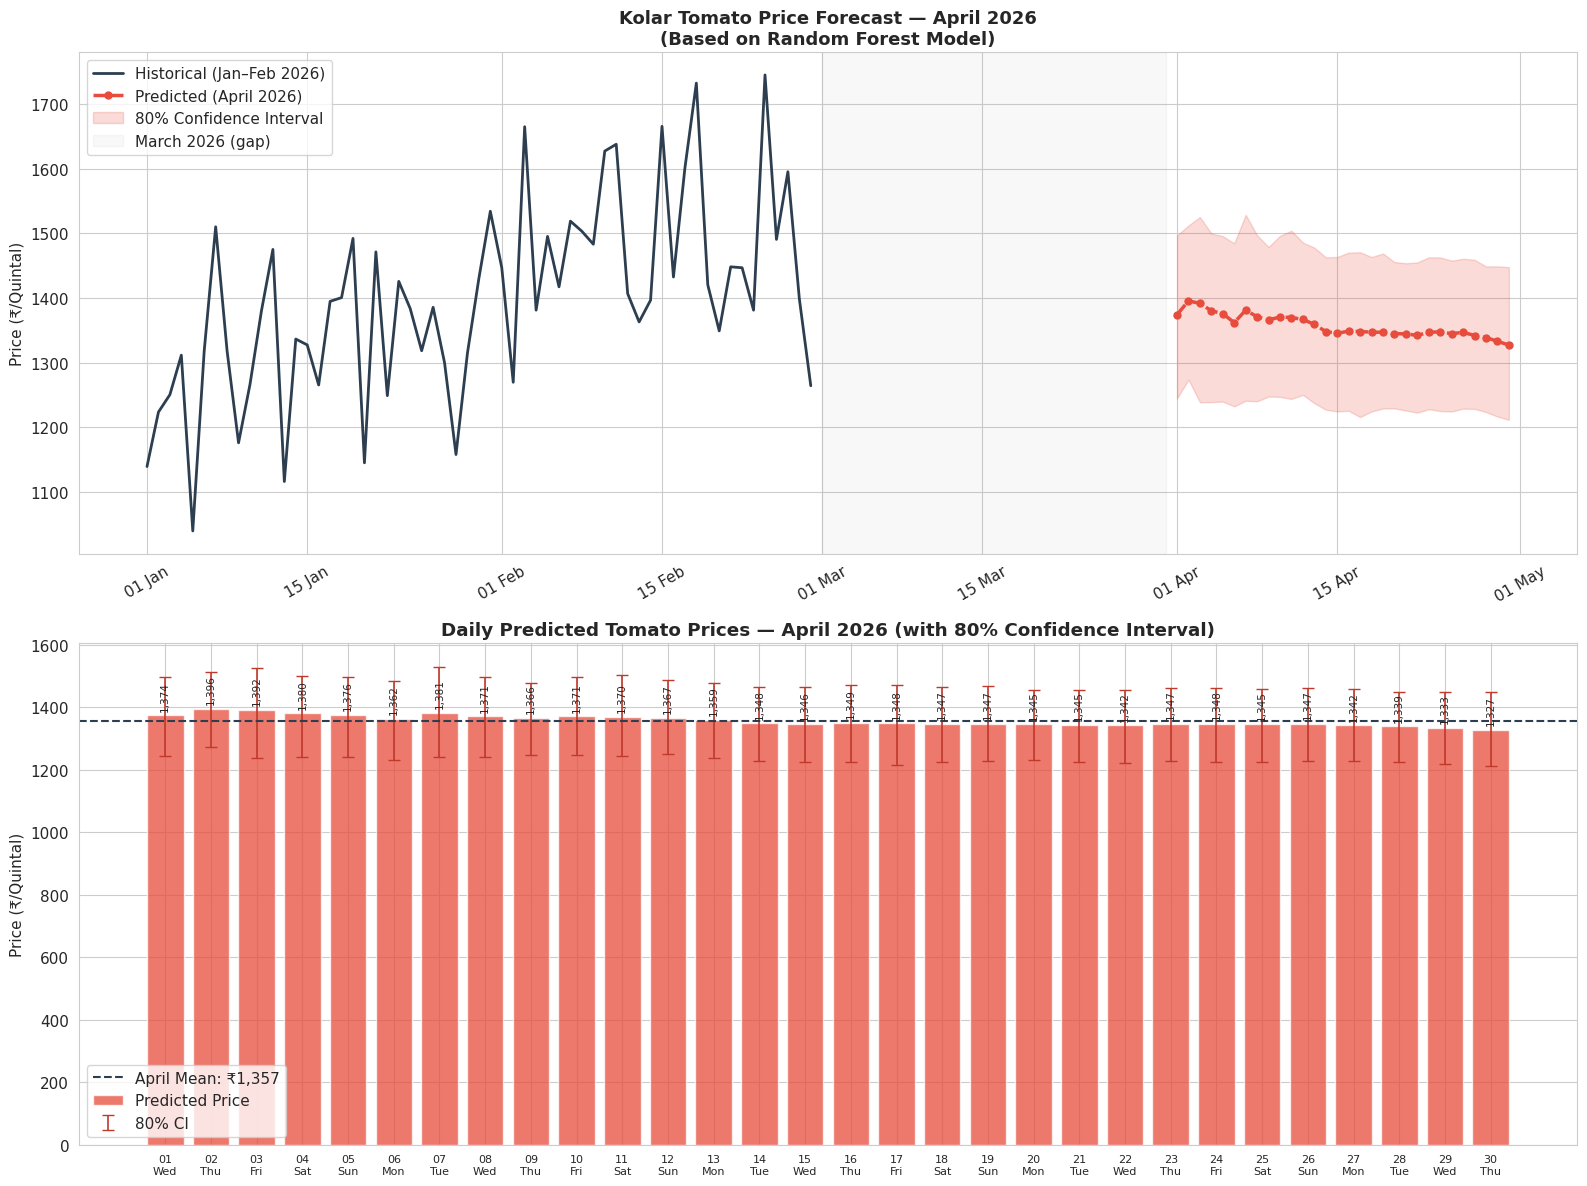

✅ Prediction charts saved!


In [18]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# ── Plot 1: Recent history + April forecast ──────────────────────────
recent_hist = df[df['date'] >= '2026-01-01'][['date','avg_price_rs_per_quintal']]

axes[0].plot(recent_hist['date'], recent_hist['avg_price_rs_per_quintal'],
             color='#2c3e50', linewidth=2, label='Historical (Jan–Feb 2026)')

axes[0].plot(april_predictions['date'],
             april_predictions['predicted_avg_price_rs_per_quintal'],
             color='#e74c3c', linewidth=2.5, linestyle='--', marker='o',
             markersize=5, label='Predicted (April 2026)')

axes[0].fill_between(april_predictions['date'],
                     april_predictions['ci_lower_10pct'],
                     april_predictions['ci_upper_90pct'],
                     alpha=0.2, color='#e74c3c', label='80% Confidence Interval')

# Mark March gap
axes[0].axvspan(pd.Timestamp('2026-03-01'), pd.Timestamp('2026-03-31'),
                alpha=0.05, color='gray', label='March 2026 (gap)')

axes[0].set_title('Kolar Tomato Price Forecast — April 2026\n(Based on Random Forest Model)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (₹/Quintal)')
axes[0].legend(loc='upper left')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.setp(axes[0].get_xticklabels(), rotation=30)

# ── Plot 2: April daily bars with CI ─────────────────────────────────
x = range(len(april_predictions))
bars = axes[1].bar(x, april_predictions['predicted_avg_price_rs_per_quintal'],
                   color='#e74c3c', alpha=0.75, edgecolor='white', label='Predicted Price')

# Error bars
yerr_lo = (april_predictions['predicted_avg_price_rs_per_quintal'] - april_predictions['ci_lower_10pct']).values
yerr_hi = (april_predictions['ci_upper_90pct'] - april_predictions['predicted_avg_price_rs_per_quintal']).values
axes[1].errorbar(x, april_predictions['predicted_avg_price_rs_per_quintal'],
                 yerr=[yerr_lo, yerr_hi],
                 fmt='none', color='#c0392b', capsize=4, linewidth=1.2, label='80% CI')

# Mean line
mean_price = april_predictions['predicted_avg_price_rs_per_quintal'].mean()
axes[1].axhline(mean_price, color='#2c3e50', linestyle='--', linewidth=1.5,
                label=f'April Mean: ₹{mean_price:,.0f}')

# Price labels on bars
for i, (idx, row) in enumerate(april_predictions.iterrows()):
    axes[1].text(i, row['predicted_avg_price_rs_per_quintal'] + 15,
                 f'{row["predicted_avg_price_rs_per_quintal"]:,.0f}',
                 ha='center', va='bottom', fontsize=7.5, rotation=90)

axes[1].set_xticks(x)
axes[1].set_xticklabels(
    [d.strftime('%d\n%a') for d in april_predictions['date']],
    fontsize=8
)
axes[1].set_title('Daily Predicted Tomato Prices — April 2026 (with 80% Confidence Interval)', fontweight='bold')
axes[1].set_ylabel('Price (₹/Quintal)')
axes[1].legend()

plt.tight_layout()
plt.savefig('april_2026_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Prediction charts saved!')

## 💾 Step 9: Save Results to CSV

In [19]:
output_df = april_predictions[['date','predicted_avg_price_rs_per_quintal','ci_lower_10pct','ci_upper_90pct']].copy()
output_df['date'] = output_df['date'].dt.strftime('%Y-%m-%d')
output_df.columns = ['date','predicted_avg_price_rs_per_quintal','ci_lower_80pct','ci_upper_80pct']

output_path = 'kolar_tomato_april_2026_predictions.csv'
output_df.to_csv(output_path, index=False)

# Download the file
files.download(output_path)
files.download('april_2026_predictions.png')
files.download('model_evaluation.png')

print(f'✅ Results saved to: {output_path}')
print(f'📥 Files downloading...')
print(output_df.to_string(index=False))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Results saved to: kolar_tomato_april_2026_predictions.csv
📥 Files downloading...
      date  predicted_avg_price_rs_per_quintal  ci_lower_80pct  ci_upper_80pct
2026-04-01                             1374.21         1244.77         1496.87
2026-04-02                             1395.66         1273.90         1512.21
2026-04-03                             1391.81         1238.99         1525.25
2026-04-04                             1380.40         1239.11         1499.90
2026-04-05                             1375.84         1239.96         1495.72
2026-04-06                             1362.08         1232.53         1484.70
2026-04-07                             1381.13         1241.26         1528.74
2026-04-08                             1371.23         1240.45         1497.07
2026-04-09                             1366.21         1247.72         1478.93
2026-04-10                             1370.78         1247.25         1496.18
2026-04-11                             1369.97  

## 📝 Step 10: Model Summary

Run this cell for a clean summary of the entire pipeline.

In [20]:
print('=' * 60)
print('       KOLAR TOMATO PRICE PREDICTION — SUMMARY')
print('=' * 60)
print(f'  Model         : Random Forest Regressor')
print(f'  Trees         : 500')
print(f'  Training data : {df_model["date"].min().date()} → {train_df["date"].max().date()}')
print(f'  Test data     : {test_df["date"].min().date()} → {test_df["date"].max().date()}')
print(f'  Features used : {len(FEATURE_COLS)}')
print()
print('  TEST SET PERFORMANCE')
print(f'    MAE   : ₹{mae:.2f}/quintal')
print(f'    RMSE  : ₹{rmse:.2f}/quintal')
print(f'    MAPE  : {mape:.2f}%')
print(f'    R²    : {r2:.4f}')
print()
print('  APRIL 2026 FORECAST')
preds = april_predictions['predicted_avg_price_rs_per_quintal']
print(f'    Min Price  : ₹{preds.min():,.2f} ({april_predictions.loc[preds.idxmin(),"date"].strftime("%d %b")})')
print(f'    Max Price  : ₹{preds.max():,.2f} ({april_predictions.loc[preds.idxmax(),"date"].strftime("%d %b")})')
print(f'    Mean Price : ₹{preds.mean():,.2f}')
print(f'    Std Dev    : ±₹{preds.std():,.2f}')
print('=' * 60)

       KOLAR TOMATO PRICE PREDICTION — SUMMARY
  Model         : Random Forest Regressor
  Trees         : 500
  Training data : 2016-03-31 → 2025-08-31
  Test data     : 2025-09-01 → 2026-02-28
  Features used : 69

  TEST SET PERFORMANCE
    MAE   : ₹43.50/quintal
    RMSE  : ₹55.62/quintal
    MAPE  : 3.95%
    R²    : 0.9460

  APRIL 2026 FORECAST
    Min Price  : ₹1,327.33 (30 Apr)
    Max Price  : ₹1,395.66 (02 Apr)
    Mean Price : ₹1,357.05
    Std Dev    : ±₹17.35
